In [1]:
# ------------------------------------------------------------------ #
#  Notebook 01 · Data Cleaning & Exploratory Data Analysis           #
#  Input : data/raw/online_retail_II.csv                             #
#  Output: data/processed/retail_clean.parquet                       #
# ------------------------------------------------------------------ #

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

RAW_PATH  = r'E:\Projects\python\E-Commerce Customer Intelligence Platform\data\raw\online_retail_II.csv'
SAVE_PATH = r'E:\Projects\python\E-Commerce Customer Intelligence Platform\data\processed\retail_clean.parquet'

os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)

In [2]:
# Load with correct dtypes upfront to avoid messy conversions later.
# Invoice and StockCode are IDs, not numbers, so we read them as strings.

df = pd.read_csv(
    RAW_PATH,
    encoding='utf-8',
    dtype={'Invoice': str, 'StockCode': str, 'Customer ID': str},
    parse_dates=['InvoiceDate']
)

print(f'Shape            : {df.shape}')
print(f'Date range       : {df.InvoiceDate.min().date()}  to  {df.InvoiceDate.max().date()}')
print(f'Unique invoices  : {df.Invoice.nunique():,}')
print(f'Unique customers : {df["Customer ID"].nunique():,}')
print(f'Countries        : {df.Country.nunique()}')
df.head()

Shape            : (1067371, 8)
Date range       : 2009-12-01  to  2011-12-09
Unique invoices  : 53,628
Unique customers : 5,942
Countries        : 43


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 1. Initial Inspection

Before cleaning anything, we audit the data as-is — null counts, data types,
and basic statistics. This gives us a baseline to measure cleaning against.

In [3]:
# Null counts and percentage of total rows for each column.
# This tells us how aggressively we need to handle missing data.

null_summary = pd.DataFrame({
    'Null Count': df.isnull().sum(),
    'Null %'    : (df.isnull().sum() / len(df) * 100).round(2)
})

print(null_summary)
print(f'\nData types:\n{df.dtypes}')

             Null Count  Null %
Invoice               0    0.00
StockCode             0    0.00
Description        4382    0.41
Quantity              0    0.00
InvoiceDate           0    0.00
Price                 0    0.00
Customer ID      243007   22.77
Country               0    0.00

Data types:
Invoice                   str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
Price                 float64
Customer ID               str
Country                   str
dtype: object


## 2. Data Cleaning

We clean in a strict order — each step is logged so we can see exactly
how many rows each decision costs us. The cleaning decisions are:

- Drop rows with no Customer ID (guest checkouts — cannot be segmented)
- Drop rows with no Description (unidentifiable products)
- Remove cancellations (Invoice starting with 'C')
- Remove rows where Quantity or Price <= 0 (returns, adjustments, errors)
- Remove known non-product StockCodes (postage, bank charges, test entries)
- Drop exact duplicate rows

In [4]:
# Each step prints a before/after count so the data loss is fully transparent.

original_count = len(df)
log = []

def clean_step(df, label):
    log.append((label, len(df)))
    return df

df = clean_step(df, 'Raw')

df = df.dropna(subset=['Customer ID'])
df = clean_step(df, 'Drop null Customer ID')

df = df.dropna(subset=['Description'])
df = clean_step(df, 'Drop null Description')

df = df[~df['Invoice'].str.startswith('C')]
df = clean_step(df, 'Remove cancellations')

df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]
df = clean_step(df, 'Remove Quantity/Price <= 0')

non_product = ['POST', 'D', 'M', 'BANK CHARGES', 'PADS', 'DOT', 'AMAZONFEE', 'CRUK', 'S', 'DCGSSBOY', 'DCGSSGIRL']
df = df[~df['StockCode'].isin(non_product)]
df = clean_step(df, 'Remove non-product StockCodes')

df = df.drop_duplicates()
df = clean_step(df, 'Drop duplicates')

# Print cleaning log as a readable table
print(f'{"Step":<30} {"Rows":>10} {"Removed":>10}')
print('-' * 52)
for i, (label, count) in enumerate(log):
    removed = log[i-1][1] - count if i > 0 else 0
    print(f'{label:<30} {count:>10,} {removed:>10,}')

print(f'\nTotal removed : {original_count - len(df):,} rows ({(original_count - len(df))/original_count*100:.1f}%)')
print(f'Clean dataset : {len(df):,} rows')

Step                                 Rows    Removed
----------------------------------------------------
Raw                             1,067,371          0
Drop null Customer ID             824,364    243,007
Drop null Description             824,364          0
Remove cancellations              805,620     18,744
Remove Quantity/Price <= 0        805,549         71
Remove non-product StockCodes     802,932      2,617
Drop duplicates                   776,872     26,060

Total removed : 290,499 rows (27.2%)
Clean dataset : 776,872 rows


## 3. Feature Engineering

We derive new columns from existing ones before any analysis begins.
`Revenue` is the core metric used in almost every downstream notebook.
The time-based columns allow us to slice data by period without recomputing.

In [5]:
# Revenue is quantity multiplied by unit price — the fundamental business metric.
# Time features are extracted once here and reused across all analyses.

df['Revenue']    = (df['Quantity'] * df['Price']).round(2)

df['Year']       = df['InvoiceDate'].dt.year
df['Month']      = df['InvoiceDate'].dt.month
df['DayOfWeek']  = df['InvoiceDate'].dt.dayofweek   # 0 = Monday, 6 = Sunday
df['Hour']       = df['InvoiceDate'].dt.hour
df['YearMonth']  = df['InvoiceDate'].dt.to_period('M')

print('Columns now:', df.columns.tolist())
df[['Invoice', 'InvoiceDate', 'Quantity', 'Price', 'Revenue', 'YearMonth']].head()

Columns now: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Revenue', 'Year', 'Month', 'DayOfWeek', 'Hour', 'YearMonth']


,Invoice,InvoiceDate,Quantity,Price,Revenue,YearMonth
0,489434,2009-12-01 07:45:00,12,6.95,83.4,2009-12
1,489434,2009-12-01 07:45:00,12,6.75,81.0,2009-12
2,489434,2009-12-01 07:45:00,12,6.75,81.0,2009-12
3,489434,2009-12-01 07:45:00,48,2.10,100.8,2009-12
4,489434,2009-12-01 07:45:00,24,1.25,30.0,2009-12


## 4. Exploratory Data Analysis

We visualise the clean dataset across four dimensions — time, products,
geography, and order behaviour. The goal is to surface patterns that will
inform the segmentation and forecasting notebooks.

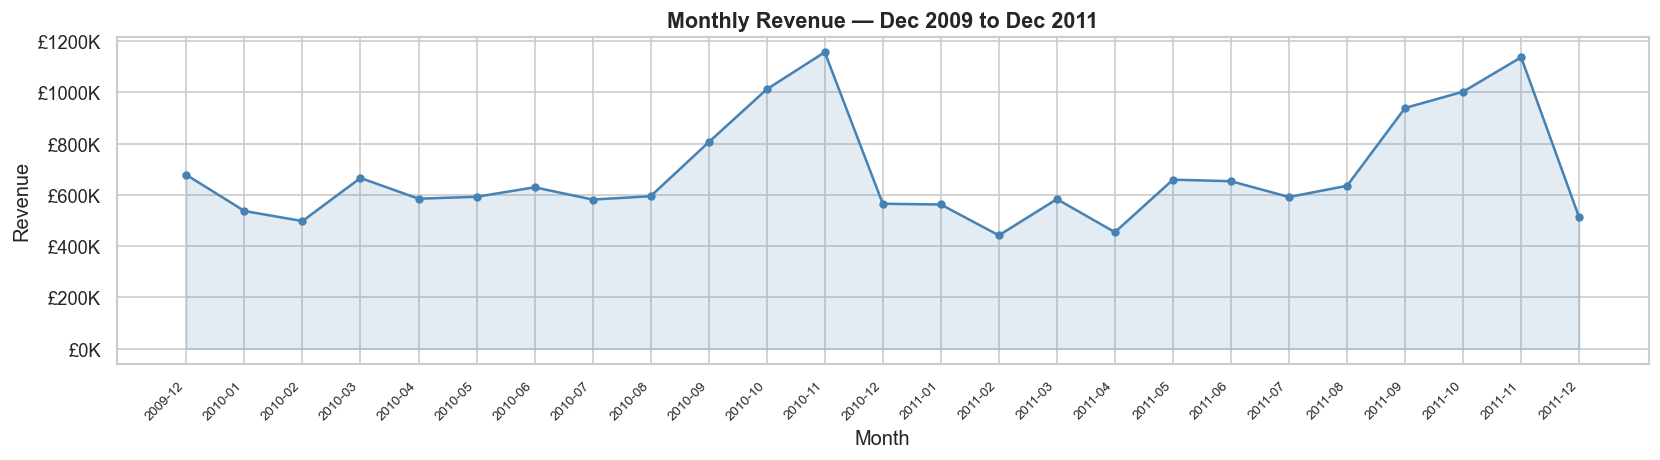

In [6]:
# Aggregate revenue by calendar month and plot as an area chart.
# This reveals seasonality and overall growth trajectory.

monthly = (
    df.groupby('YearMonth')['Revenue']
    .sum()
    .reset_index()
)
monthly['YearMonth_str'] = monthly['YearMonth'].astype(str)

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(monthly['YearMonth_str'], monthly['Revenue'], alpha=0.15, color='steelblue')
ax.plot(monthly['YearMonth_str'], monthly['Revenue'], marker='o', ms=4, color='steelblue')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
ax.set_title('Monthly Revenue — Dec 2009 to Dec 2011', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

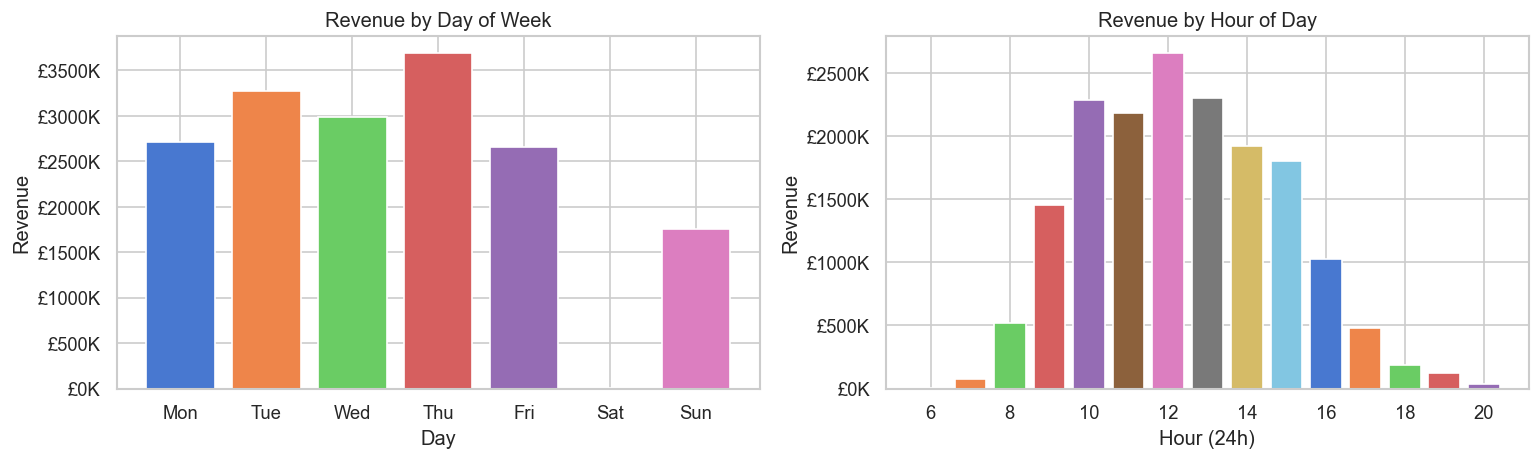

In [7]:
# Identifies when customers are most active.
# Useful context for marketing timing and operational planning.

day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

dow = df.groupby('DayOfWeek')['Revenue'].sum()
axes[0].bar(
    [day_labels[i] for i in dow.index],
    dow.values,
    color=sns.color_palette('muted', len(dow))
)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
axes[0].set_title('Revenue by Day of Week')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Revenue')

hour = df.groupby('Hour')['Revenue'].sum()
axes[1].bar(
    hour.index,
    hour.values,
    color=sns.color_palette('muted', len(hour))
)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
axes[1].set_title('Revenue by Hour of Day')
axes[1].set_xlabel('Hour (24h)')
axes[1].set_ylabel('Revenue')

plt.tight_layout()
plt.show()

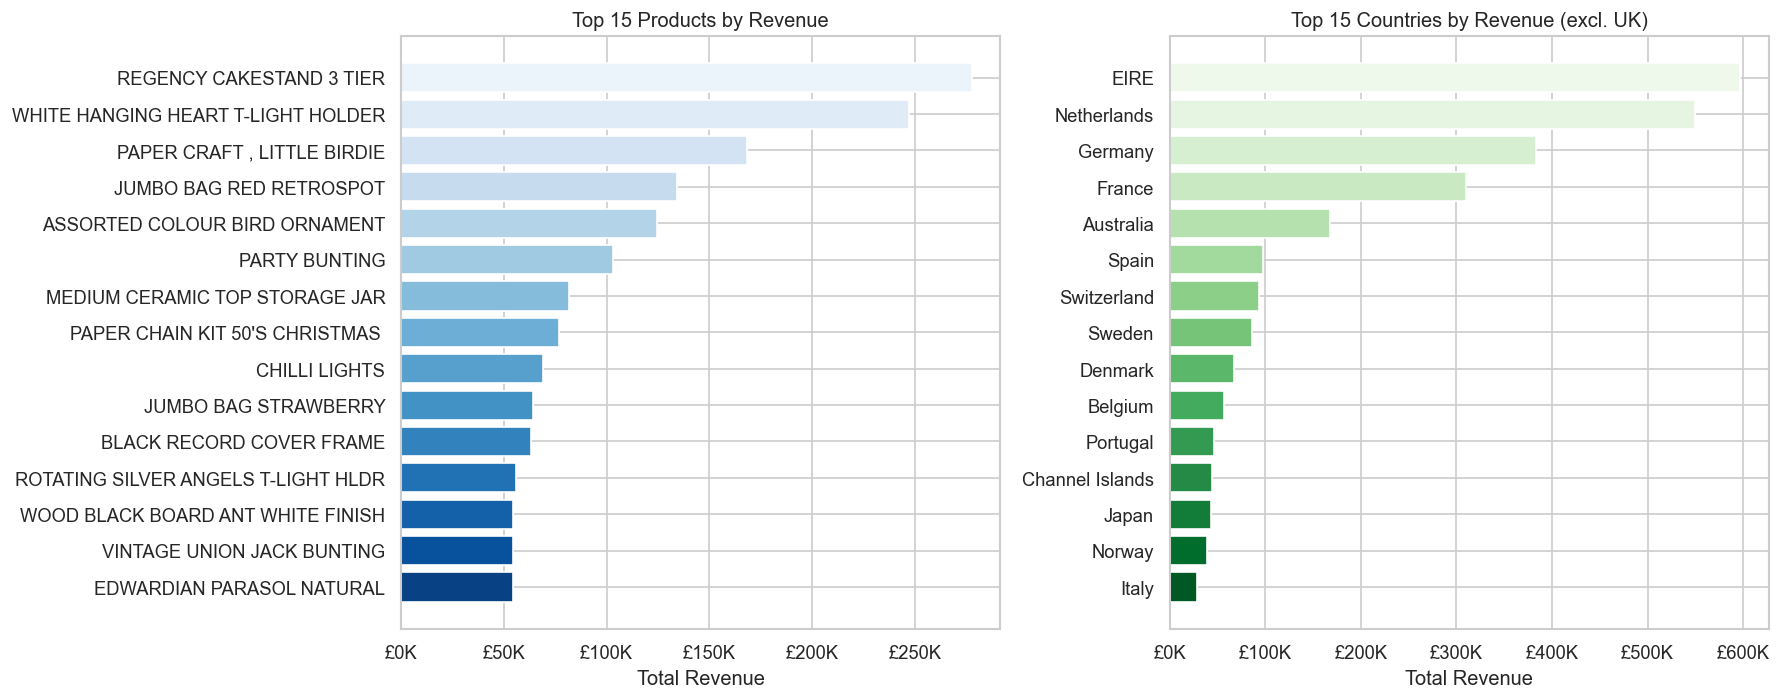

In [8]:
# Top 15 products by total revenue and top countries excluding the UK.
# UK dominates volume so we separate it to see international distribution clearly.

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

top_products = (
    df.groupby('Description')['Revenue']
    .sum()
    .nlargest(15)
    .sort_values()
)
axes[0].barh(
    top_products.index,
    top_products.values,
    color=sns.color_palette('Blues_r', len(top_products))
)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
axes[0].set_title('Top 15 Products by Revenue')
axes[0].set_xlabel('Total Revenue')

top_countries = (
    df[df['Country'] != 'United Kingdom']
    .groupby('Country')['Revenue']
    .sum()
    .nlargest(15)
    .sort_values()
)
axes[1].barh(
    top_countries.index,
    top_countries.values,
    color=sns.color_palette('Greens_r', len(top_countries))
)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e3:.0f}K'))
axes[1].set_title('Top 15 Countries by Revenue (excl. UK)')
axes[1].set_xlabel('Total Revenue')

plt.tight_layout()
plt.show()

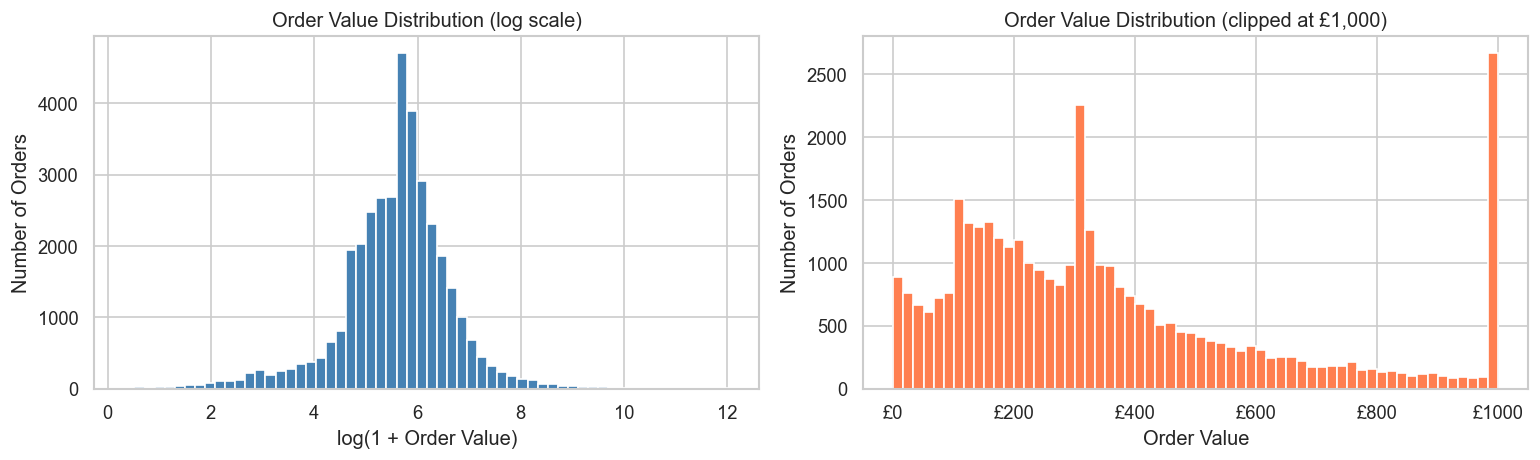

Order Value Statistics
  Mean   : £466.25
  Median : £302.57
  Std    : £1,357.98
  Min    : £0.38
  Max    : £168,469.60
  Orders > £1,000 : 2,583 (7.0%)


In [9]:
# Order-level aggregation (not line-item level) gives a truer picture
# of what customers actually spend per visit.

order_totals = df.groupby('Invoice')['Revenue'].sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Most orders cluster at low values — log scale makes the distribution readable
axes[0].hist(np.log1p(order_totals), bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Order Value Distribution (log scale)')
axes[0].set_xlabel('log(1 + Order Value)')
axes[0].set_ylabel('Number of Orders')

# Clipped view to see the bulk of orders without extreme outliers distorting the axis
axes[1].hist(order_totals.clip(upper=1000), bins=60, color='coral', edgecolor='white')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:.0f}'))
axes[1].set_title('Order Value Distribution (clipped at £1,000)')
axes[1].set_xlabel('Order Value')
axes[1].set_ylabel('Number of Orders')

plt.tight_layout()
plt.show()

# Summary statistics at the order level
print('Order Value Statistics')
print(f'  Mean   : £{order_totals.mean():,.2f}')
print(f'  Median : £{order_totals.median():,.2f}')
print(f'  Std    : £{order_totals.std():,.2f}')
print(f'  Min    : £{order_totals.min():,.2f}')
print(f'  Max    : £{order_totals.max():,.2f}')
print(f'  Orders > £1,000 : {(order_totals > 1000).sum():,} ({(order_totals > 1000).mean()*100:.1f}%)')


## 5. Save Clean Dataset

The cleaned dataframe is saved as Parquet — a columnar format that is
significantly faster to read than CSV for large datasets. All downstream
notebooks load from this file rather than re-running the cleaning steps.

In [10]:
# YearMonth is a Period type which Parquet does not support.
# We convert it to string before saving and reconstruct it when needed downstream.

df['YearMonth'] = df['YearMonth'].astype(str)

df.to_parquet(SAVE_PATH, index=False)

print(f'Saved  : {SAVE_PATH}')
print(f'Rows   : {len(df):,}')
print(f'Columns: {df.columns.tolist()}')
print(f'Size   : {os.path.getsize(SAVE_PATH) / 1e6:.1f} MB')

Saved  : E:\Projects\python\E-Commerce Customer Intelligence Platform\data\processed\retail_clean.parquet
Rows   : 776,872
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'Revenue', 'Year', 'Month', 'DayOfWeek', 'Hour', 'YearMonth']
Size   : 6.2 MB
